<a href="https://colab.research.google.com/github/Karishmaaa22/ML-safety/blob/main/Exercise7%20%2C8%20and%209.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
train_path = "/content/drive/MyDrive/Data2/train"
test_path = "/content/drive/MyDrive/Data2/test"

In [3]:
train_rgb_path=train_path+"/rgb-front"
test_rgb_path=test_path+"/rgb-front"

In [4]:
import pandas as pd
labels_train = pd.read_csv(train_path + "/labels.csv")
labels_test = pd.read_csv(test_path + "/labels.csv")

In [5]:
import torch
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


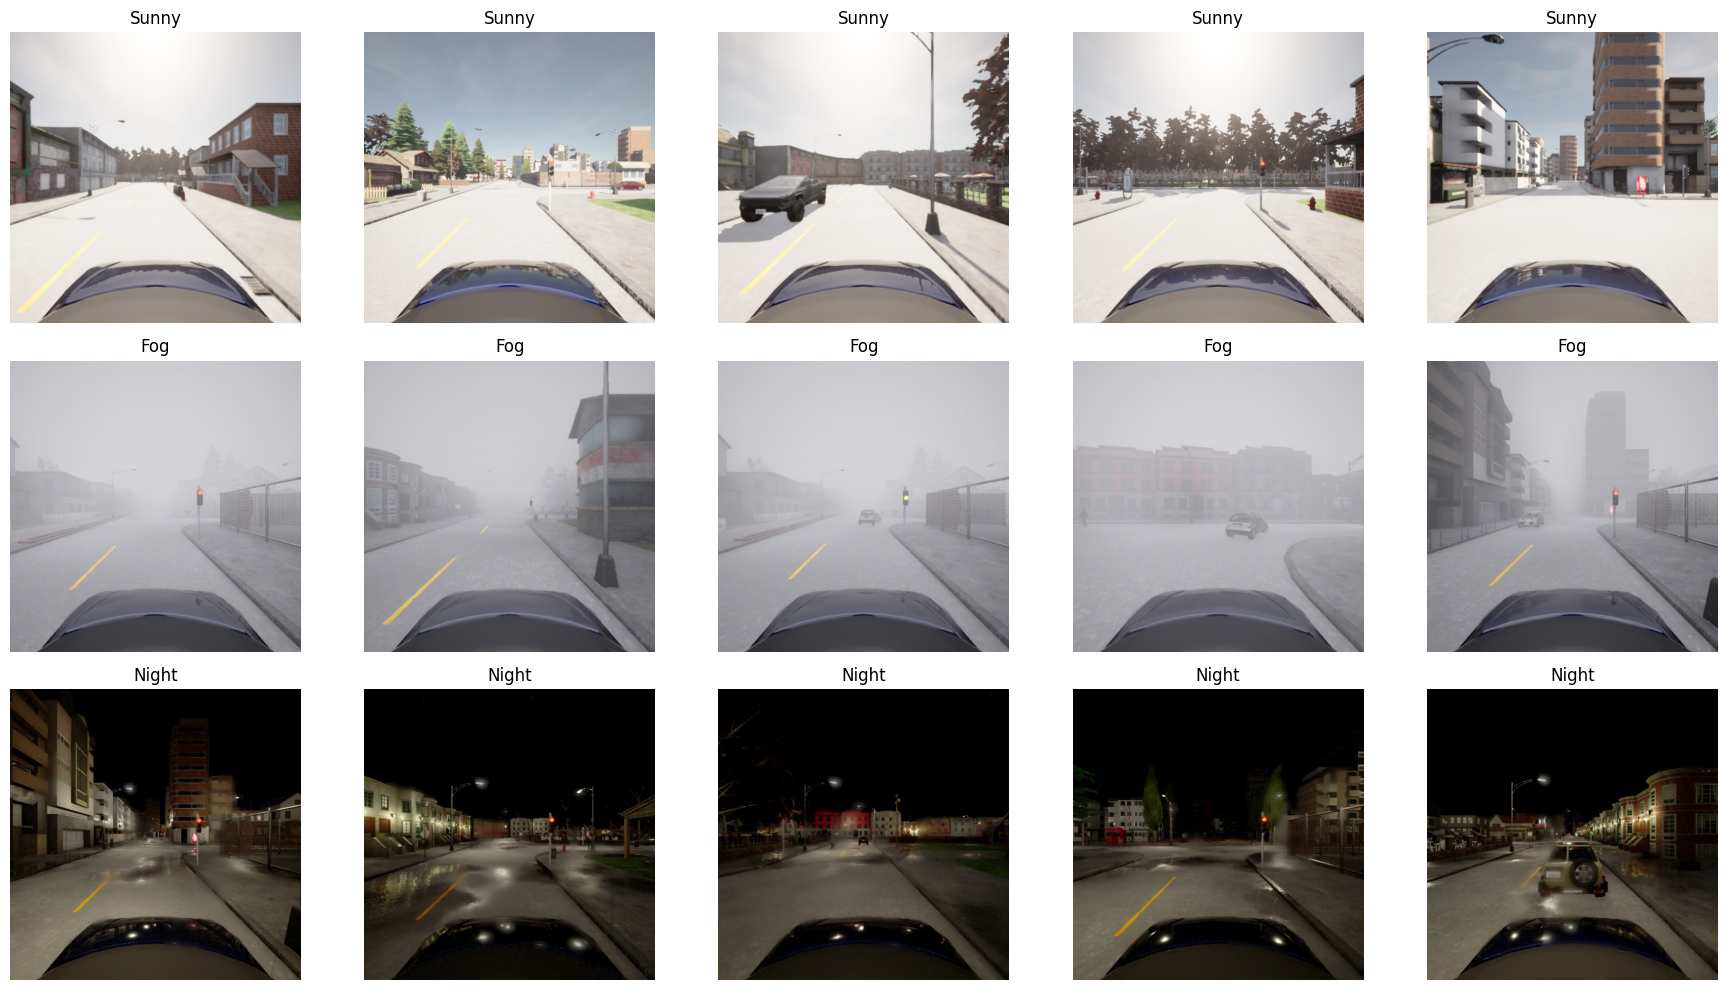

In [ ]:
import os
import random
from PIL import Image
import matplotlib.pyplot as plt
# IMAGE DIRECTORIES
train_rgb_path=train_path+"/rgb-front"
id_path = train_rgb_path

fog_path = "/content/drive/MyDrive/Data2/test-fog/rgb-front"

night_path = "/content/drive/MyDrive/Data2/test-night/rgb-front"

id_images = random.sample(
    os.listdir(id_path),
    5
)

fog_images = random.sample(
    os.listdir(fog_path),
    5
)

night_images = random.sample(
    os.listdir(night_path),
    5
)

fig, axes = plt.subplots(
    3,
    5,
    figsize=(18,10)
)

# Row 1: In-Distribution
for i, img_name in enumerate(id_images):

    img = Image.open(
        os.path.join(id_path, img_name)
    )

    axes[0, i].imshow(img)

    axes[0, i].set_title("Sunny")

    axes[0, i].axis("off")

# Row 2: Fog
for i, img_name in enumerate(fog_images):

    img = Image.open(
        os.path.join(fog_path, img_name)
    )

    axes[1, i].imshow(img)

    axes[1, i].set_title("Fog")

    axes[1, i].axis("off")

# Row 3: Night
for i, img_name in enumerate(night_images):

    img = Image.open(
        os.path.join(night_path, img_name)
    )

    axes[2, i].imshow(img)

    axes[2, i].set_title("Night")

    axes[2, i].axis("off")

plt.tight_layout()

plt.show()

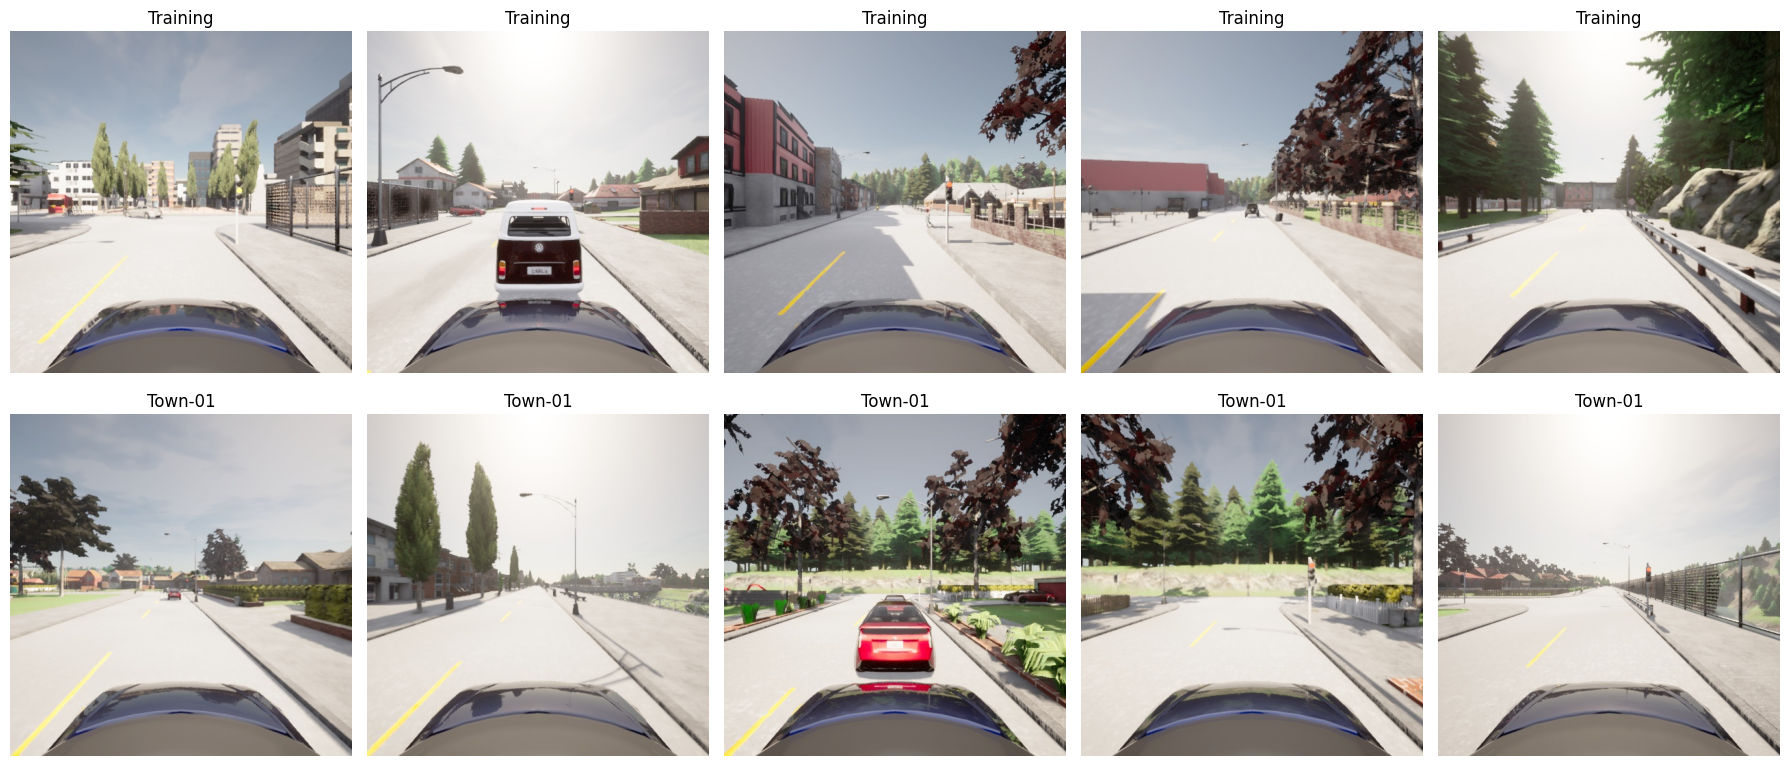

In [ ]:
train_path = train_rgb_path

town_path = "/content/drive/MyDrive/Data2/test-town-01/rgb-front"

train_images = random.sample(
    os.listdir(train_path),
    5
)

town_images = random.sample(
    os.listdir(town_path),
    5
)


fig, axes = plt.subplots(
    2,
    5,
    figsize=(18,8)
)

for i, img_name in enumerate(train_images):

    img = Image.open(
        os.path.join(train_path, img_name)
    )

    axes[0, i].imshow(img)

    axes[0, i].set_title("Training")

    axes[0, i].axis("off")

for i, img_name in enumerate(town_images):

    img = Image.open(
        os.path.join(town_path, img_name)
    )

    axes[1, i].imshow(img)

    axes[1, i].set_title("Town-01")

    axes[1, i].axis("off")

plt.tight_layout()

plt.show()

In [6]:
from torch.utils.data import DataLoader
import numpy as np

def mean_confidence(model, dataset):

    loader = DataLoader(
        dataset,
        batch_size=16,
        shuffle=False
    )

    confidences = []

    model.eval()

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)

            outputs = model(images)

            probs = torch.sigmoid(outputs)

            # confidence of predicted class
            conf = torch.maximum(
                probs,
                1 - probs
            )

            confidences.extend(
                conf.cpu().numpy().flatten()
            )

    return np.mean(confidences)

In [7]:
from torchvision import transforms

transform = transforms.Compose([

    transforms.Resize((224, 224)),

    transforms.ToTensor()

])

In [8]:
import torch.nn as nn
from torchvision import models

def create_model():

    model = models.resnet18(

        weights=models.ResNet18_Weights.DEFAULT
    )

    model.fc = nn.Linear(

        model.fc.in_features,

        1
    )

    return model

In [9]:
from torch.utils.data import Dataset
from PIL import Image
import os
import torch

class CarlaDataset(Dataset):

    def __init__(

        self,

        dataframe,

        image_dir,

        label_column,

        transform=None
    ):

        self.dataframe = dataframe

        self.image_dir = image_dir

        self.label_column = label_column

        self.transform = transform

        self.image_files = sorted(
            os.listdir(image_dir)
        )

    def __len__(self):

        return len(self.dataframe)

    def __getitem__(self, idx):

        image_name = self.image_files[idx]

        image_path = os.path.join(

            self.image_dir,

            image_name
        )

        image = Image.open(

            image_path

        ).convert("RGB")

        label = torch.tensor(

            self.dataframe.iloc[idx][self.label_column],

            dtype=torch.float32
        )

        if self.transform:

            image = self.transform(image)

        return image, label

In [ ]:
splits = {

    "In-Distribution":
    "/content/drive/MyDrive/Data2/test",

    "Fog":
    "/content/drive/MyDrive/Data2/test-fog",

    "Night":
    "/content/drive/MyDrive/Data2/test-night"
}

tasks = [
    "has_pedestrian",
    "has_traffic_light",
    "has_vehicle"
]

for task in tasks:
    print(task)
    model = create_model().to(device)

    model.load_state_dict(
        torch.load(
            f"/content/drive/MyDrive/Data2/model/{task}_model.pth",
            map_location=device
        )
    )

    for split_name, split_path in splits.items():

        labels = pd.read_csv(
            split_path + "/labels.csv"
        )

        dataset = CarlaDataset(
            dataframe=labels,
            image_dir=split_path + "/rgb-front",
            label_column=task,
            transform=transform
        )

        confidence = mean_confidence(
            model,
            dataset
        )

        print(
            f"{split_name}: "
            f"{confidence:.4f}"
        )

has_pedestrian
In-Distribution: 0.9696
Fog: 0.9362
Night: 0.8729
has_traffic_light
In-Distribution: 0.9538
Fog: 0.9090
Night: 0.8735
has_vehicle
In-Distribution: 0.9523
Fog: 0.9957
Night: 0.9791


In [ ]:
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt

def get_ood_scores(model, dataset):

    loader = DataLoader(
        dataset,
        batch_size=64,
        shuffle=False
    )

    scores = []

    model.eval()

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)

            outputs = model(images)

            probs = torch.sigmoid(outputs)

            confidence = torch.maximum(
                probs,
                1 - probs
            )

            ood_score = 1 - confidence

            scores.extend(
                ood_score.cpu().numpy().flatten()
            )

    return np.array(scores)

In [10]:
labels_test = pd.read_csv(
    "/content/drive/MyDrive/Data2/test/labels.csv"
)

labels_fog = pd.read_csv(
    "/content/drive/MyDrive/Data2/test-fog/labels.csv"
)

labels_night = pd.read_csv(
    "/content/drive/MyDrive/Data2/test-night/labels.csv"
)
labels_val=pd.read_csv(
    "/content/drive/MyDrive/Data2/validation/labels.csv"
    )

In [ ]:
ped_model = create_model().to(device)

ped_model.load_state_dict(
    torch.load(
        "/content/drive/MyDrive/Data2/model/has_pedestrian_model.pth",
        map_location=device
    )
)

<All keys matched successfully>

In [11]:
test_rgb_path= test_path+"/rgb-front"
fog_rgb_path="/content/drive/MyDrive/Data2/test-fog/rgb-front"
night_rgb_path="/content/drive/MyDrive/Data2/test-night/rgb-front"
id_dataset = CarlaDataset(
    labels_test,
    test_rgb_path,
    "has_pedestrian",
    transform
)

fog_dataset = CarlaDataset(
    labels_fog,
    fog_rgb_path,
    "has_pedestrian",
    transform
)

night_dataset = CarlaDataset(
    labels_night,
    night_rgb_path,
    "has_pedestrian",
    transform
)

In [ ]:
id_scores = get_ood_scores(
    ped_model,
    id_dataset
)

fog_scores = get_ood_scores(
    ped_model,
    fog_dataset
)

night_scores = get_ood_scores(
    ped_model,
    night_dataset
)

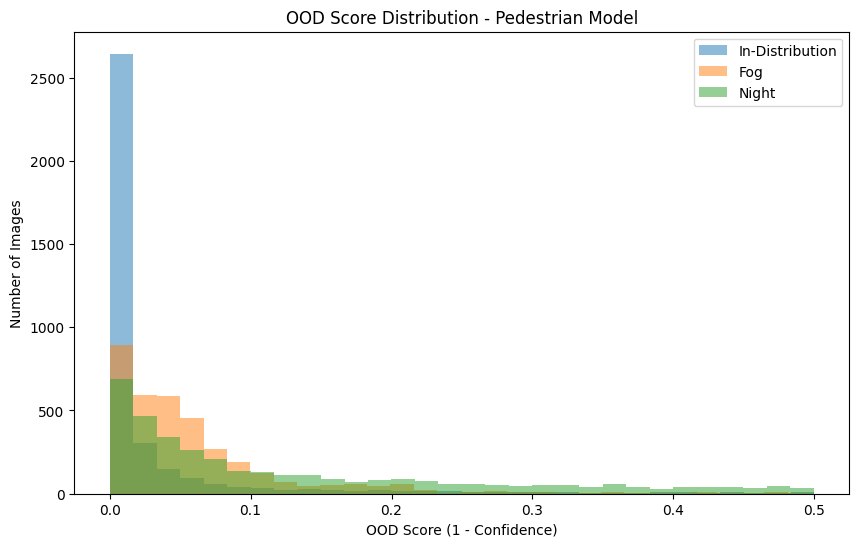

In [ ]:
plt.figure(figsize=(10,6))

plt.hist(
    id_scores,
    bins=30,
    alpha=0.5,
    label="In-Distribution"
)

plt.hist(
    fog_scores,
    bins=30,
    alpha=0.5,
    label="Fog"
)

plt.hist(
    night_scores,
    bins=30,
    alpha=0.5,
    label="Night"
)

plt.xlabel("OOD Score (1 - Confidence)")
plt.ylabel("Number of Images")
plt.title(
    "OOD Score Distribution - Pedestrian Model"
)

plt.legend()

plt.show()

In [ ]:
from sklearn.metrics import roc_auc_score
import numpy as np

y_true_fog = np.concatenate([
    np.zeros(len(id_scores)),   # In-Distribution
    np.ones(len(fog_scores))    # OOD
])

y_scores_fog = np.concatenate([
    id_scores,
    fog_scores
])

auroc_fog = roc_auc_score(
    y_true_fog,
    y_scores_fog
)

print("AUROC (Fog):", auroc_fog)

AUROC (Fog): 0.8047282407407407


In [ ]:
y_true_night = np.concatenate([
    np.zeros(len(id_scores)),
    np.ones(len(night_scores))
])

y_scores_night = np.concatenate([
    id_scores,
    night_scores
])

auroc_night = roc_auc_score(
    y_true_night,
    y_scores_night
)

print("AUROC (Night):", auroc_night)

AUROC (Night): 0.8440768518518519


In [ ]:
combined_ood_scores = np.concatenate([
    fog_scores,
    night_scores
])

y_true_all = np.concatenate([
    np.zeros(len(id_scores)), #in distribution
    np.ones(len(combined_ood_scores)) #combined OOD
])

y_scores_all = np.concatenate([
    id_scores,
    combined_ood_scores
])

auroc_all = roc_auc_score(
    y_true_all,
    y_scores_all
)

print("AUROC (All OOD):", auroc_all)

In [ ]:
import torch
import torch.nn as nn
from torchvision import models
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

feature_extractor = nn.Sequential(*list(model.children())[:-1])

feature_extractor = feature_extractor.to(device)
feature_extractor.eval()

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 141MB/s]


Sequential(
  (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU(inplace=True)
  (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (4): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)


In [ ]:
from torch.utils.data import DataLoader
import numpy as np

def extract_features(dataset):

    loader = DataLoader(
        dataset,
        batch_size=64,
        shuffle=False
    )

    features = []

    with torch.no_grad():

        for images, _ in loader:

            images = images.to(device)

            feats = feature_extractor(images)

            feats = feats.view(
                feats.size(0),
                -1
            )

            features.append(
                feats.cpu().numpy()
            )

    return np.vstack(features)

In [ ]:
train_dataset = CarlaDataset(
    labels_train,
    train_rgb_path,
    "has_pedestrian",
    transform
)

id_dataset = CarlaDataset(
    labels_test,
    test_rgb_path,
    "has_pedestrian",
    transform
)

fog_dataset = CarlaDataset(
    labels_fog,
    fog_rgb_path,
    "has_pedestrian",
    transform
)

night_dataset = CarlaDataset(
    labels_night,
    night_rgb_path,
    "has_pedestrian",
    transform
)

In [ ]:
train_features = extract_features(
    train_dataset
)

id_features = extract_features(
    id_dataset
)

fog_features = extract_features(
    fog_dataset
)

night_features = extract_features(
    night_dataset
)

print(train_features.shape)
print(id_features.shape)
print(fog_features.shape)
print(night_features.shape)

In [ ]:
print("Dataset length:", len(dataset))
print("Positive labels:", sum(int(dataset[i][1].item()) for i in range(len(dataset))))

In [ ]:
from sklearn.neighbors import NearestNeighbors

knn = NearestNeighbors(
    n_neighbors=4,
    metric="euclidean"
)

knn.fit(train_features)
#Score In-distribution test images
id_distances, _ = knn.kneighbors(
    id_features
)

id_scores = id_distances.flatten()

In [ ]:
fog_distances, _ = knn.kneighbors(
    fog_features
)

fog_scores = fog_distances.flatten()

In [ ]:
night_distances, _ = knn.kneighbors(
    night_features
)

night_scores = night_distances.flatten()

In [ ]:
print("Mean ID Distance:",
      np.mean(id_scores))

print("Mean Fog Distance:",
      np.mean(fog_scores))

print("Mean Night Distance:",
      np.mean(night_scores))

In [ ]:
from sklearn.metrics import roc_auc_score
import numpy as np
#Fog AUROC
y_true_fog = np.concatenate([
    np.zeros(len(id_scores)),
    np.ones(len(fog_scores))
])

y_scores_fog = np.concatenate([
    id_scores,
    fog_scores
])

auroc_fog_knn = roc_auc_score(
    y_true_fog,
    y_scores_fog
)

print("k-NN AUROC (Fog):",
      auroc_fog_knn)
#Night AUROC

y_true_night = np.concatenate([
    np.zeros(len(id_scores)),
    np.ones(len(night_scores))
])

y_scores_night = np.concatenate([
    id_scores,
    night_scores
])

auroc_night_knn = roc_auc_score(
    y_true_night,
    y_scores_night
)

print("k-NN AUROC (Night):",
      auroc_night_knn)

# ALL OOD AUROC

all_ood_scores = np.concatenate([
    fog_scores,
    night_scores
])

y_true_all = np.concatenate([
    np.zeros(len(id_scores)),
    np.ones(len(all_ood_scores))
])

y_scores_all = np.concatenate([
    id_scores,
    all_ood_scores
])

auroc_all_knn = roc_auc_score(
    y_true_all,
    y_scores_all
)

print("k-NN AUROC (All OOD):",
      auroc_all_knn)

### Exercise 8th

In [ ]:
task = "has_pedestrian"

model = create_model().to(device)

model.load_state_dict(
    torch.load(
        f"/content/drive/MyDrive/Data2/model/{task}_model.pth",
        map_location=device
    )
)

model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [ ]:
dataset = CarlaDataset(
    labels_test,
    test_rgb_path,
    task,
    transform
)

image, label = dataset[0]

print(label)

tensor(0.)


In [19]:
import torch
import torch.nn.functional as F

def fgsm_attack(image, epsilon, gradient):

    perturbed = image + epsilon * gradient.sign()

    perturbed = torch.clamp(
        perturbed,
        0,
        1
    )

    return perturbed


In [ ]:
def generate_adversarial_example(
    model,
    image,
    label,
    epsilon
):

    model.eval()

    image = image.unsqueeze(0).to(device)

    label = torch.tensor(
        [[float(label)]],
        device=device
    )

    image.requires_grad = True

    output = model(image)

    loss = F.binary_cross_entropy_with_logits(
        output,
        label
    )

    model.zero_grad()

    loss.backward()
    print("Gradient max :", image.grad.max().item())
    print("Gradient min :", image.grad.min().item())
    print("Gradient mean:", image.grad.mean().item())

    gradient = image.grad

    adv_image = fgsm_attack(
        image,
        epsilon,
        gradient
    )

    return adv_image.squeeze(0).detach()

In [ ]:
epsilon = 0.01

adv_image = generate_adversarial_example(
    model,
    image,
    label,
    epsilon
)

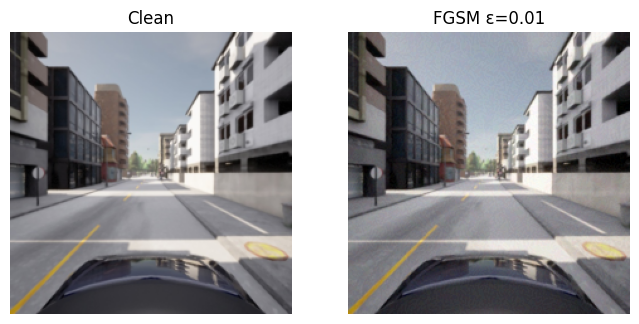

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(image.permute(1,2,0))
plt.title("Clean")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(adv_image.cpu().permute(1,2,0))
plt.title(f"FGSM ε={epsilon}")
plt.axis("off")

plt.show()


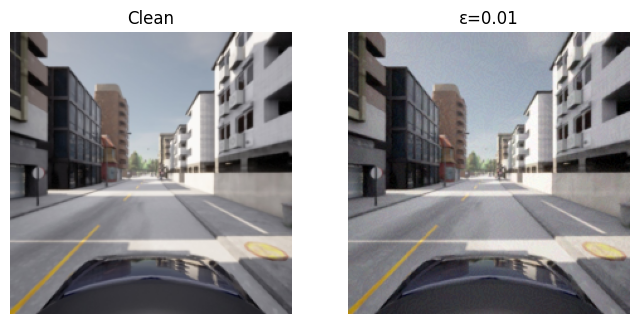

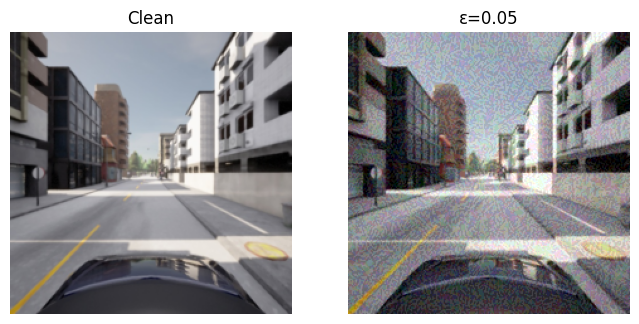

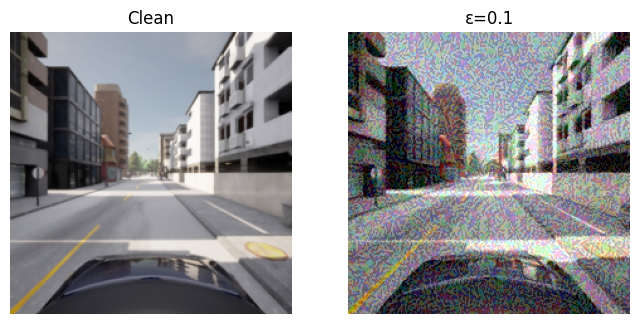

In [ ]:
epsilons = [0.01, 0.05, 0.1]

for eps in epsilons:

    adv = generate_adversarial_example(
        model,
        image,
        label,
        eps
    )

    plt.figure(figsize=(8,4))

    plt.subplot(1,2,1)
    plt.imshow(image.permute(1,2,0))
    plt.title("Clean")
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.imshow(adv.cpu().permute(1,2,0))
    plt.title(f"ε={eps}")
    plt.axis("off")

    plt.show()

In [ ]:
index = 105

image, label = dataset[index]

print("Label:", label.item())

Label: 1.0


In [ ]:
model.eval()

with torch.no_grad():

    output = model(
        image.unsqueeze(0).to(device)
    )

    prob = torch.sigmoid(output).item()

    pred = int(prob > 0.5)

print(f"Ground Truth : {int(label.item())}")
print(f"Probability  : {prob:.4f}")
print(f"Prediction   : {pred}")

Ground Truth : 1
Probability  : 0.0002
Prediction   : 0


In [ ]:
model.eval()

for i in range(len(dataset)):

    image, label = dataset[i]

    if label.item() != 1:
        continue

    with torch.no_grad():

        output = model(
            image.unsqueeze(0).to(device)
        )

        pred = int(
            torch.sigmoid(output).item() > 0.5
        )

    if pred == 1:

        print(f"Correctly classified positive image found at index {i}")

        break

Correctly classified positive image found at index 260


In [ ]:
index = 260

image, label = dataset[index]

print("Label:", label.item())

Label: 1.0


In [ ]:
model.eval()

with torch.no_grad():

    output = model(
        image.unsqueeze(0).to(device)
    )

    prob = torch.sigmoid(output).item()

    pred = int(prob > 0.5)

print(f"Ground Truth : {int(label.item())}")
print(f"Probability  : {prob:.4f}")
print(f"Prediction   : {pred}")

Ground Truth : 1
Probability  : 0.7619
Prediction   : 1


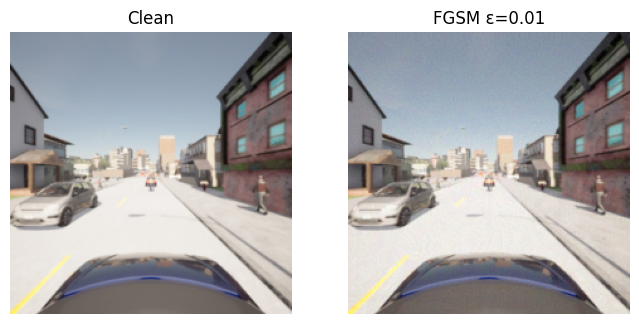

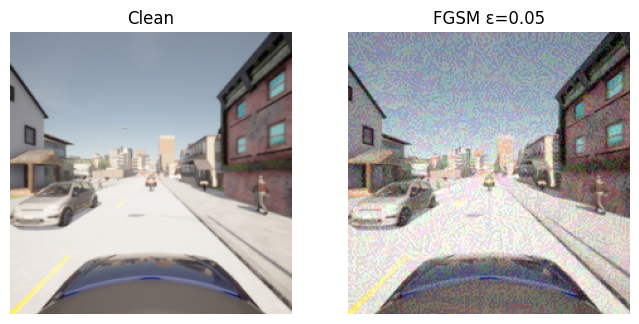

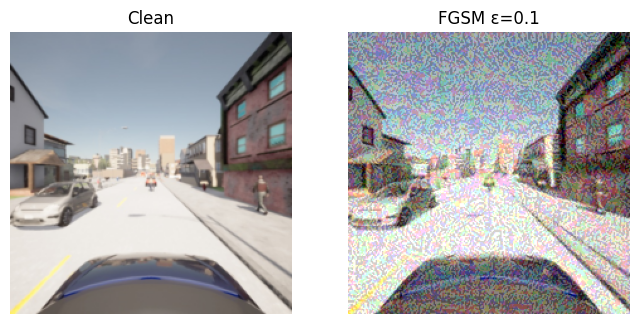

In [ ]:
index = 260

image, label = dataset[index]

epsilons = [0.01, 0.05, 0.1]

for eps in epsilons:

    adv_image = generate_adversarial_example(
        model,
        image,
        label,
        eps
    )

    plt.figure(figsize=(8,4))

    plt.subplot(1,2,1)
    plt.imshow(image.permute(1,2,0))
    plt.title("Clean")
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.imshow(adv_image.cpu().permute(1,2,0))
    plt.title(f"FGSM ε={eps}")
    plt.axis("off")

    plt.show()

In [ ]:
with torch.no_grad():

    output = model(
        adv_image.unsqueeze(0).to(device)
    )

    prob = torch.sigmoid(output).item()

    pred = int(prob > 0.5)

print(f"Epsilon      : {eps}")
print(f"Probability  : {prob:.4f}")
print(f"Prediction   : {pred}")

Epsilon      : 0.1
Probability  : 0.1254
Prediction   : 0


In [ ]:
difference = (adv_image - image.to(device)).abs()

print("Maximum perturbation :", difference.max().item())
print("Mean perturbation    :", difference.mean().item())

Maximum perturbation : 0.10000002384185791
Mean perturbation    : 0.09801378846168518


In [ ]:
eps = 0.01

adv_image = generate_adversarial_example(
    model,
    image,
    label,
    eps
)

with torch.no_grad():

    output = model(
        adv_image.unsqueeze(0).to(device)
    )

    prob = torch.sigmoid(output).item()

    pred = int(prob > 0.5)

print(f"Epsilon     : {eps}")
print(f"Probability : {prob:.4f}")
print(f"Prediction  : {pred}")

Epsilon     : 0.01
Probability : 0.0000
Prediction  : 0


In [ ]:
difference = (adv_image - image.to(device)).abs()

print("Maximum perturbation :", difference.max().item())
print("Mean perturbation    :", difference.mean().item())

Maximum perturbation : 0.010000020265579224
Mean perturbation    : 0.00999654270708561


In [ ]:
eps = 0.05
adv_image = generate_adversarial_example(
    model,
    image,
    label,
    eps
)

with torch.no_grad():

    output = model(
        adv_image.unsqueeze(0).to(device)
    )

    prob = torch.sigmoid(output).item()

    pred = int(prob > 0.5)

print(f"Epsilon     : {eps}")
print(f"Probability : {prob:.4f}")
print(f"Prediction  : {pred}")

Epsilon     : 0.05
Probability : 0.0027
Prediction  : 0


In [ ]:
difference = (adv_image - image.to(device)).abs()

print("Maximum perturbation :", difference.max().item())
print("Mean perturbation    :", difference.mean().item())

Maximum perturbation : 0.050000011920928955
Mean perturbation    : 0.049919743090867996


In [ ]:
task = "has_traffic_light"

model = create_model().to(device)

model.load_state_dict(
    torch.load(
        f"/content/drive/MyDrive/Data2/model/{task}_model.pth",
        map_location=device
    )
)

model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [ ]:
dataset = CarlaDataset(
    labels_test,
    test_rgb_path,
    task,
    transform
)

print("Dataset loaded successfully.")

Dataset loaded successfully.


In [ ]:
model.eval()

for i in range(len(dataset)):

    image, label = dataset[i]

    if label.item() != 1:
        continue

    with torch.no_grad():

        output = model(
            image.unsqueeze(0).to(device)
        )

        prob = torch.sigmoid(output).item()

        pred = int(prob > 0.5)

    if pred == 1:

        print(f"Correctly classified image found at index {i}")
        print(f"Probability : {prob:.4f}")

        break

Correctly classified image found at index 1
Probability : 0.9965


In [ ]:
index = 1

image, label = dataset[index]

print("Ground Truth :", int(label.item()))

with torch.no_grad():

    output = model(
        image.unsqueeze(0).to(device)
    )

    prob = torch.sigmoid(output).item()

    pred = int(prob > 0.5)

print(f"Probability : {prob:.4f}")
print(f"Prediction  : {pred}")

Ground Truth : 1
Probability : 0.9965
Prediction  : 1



Epsilon     : 0.01
Probability : 0.0002
Prediction  : 0


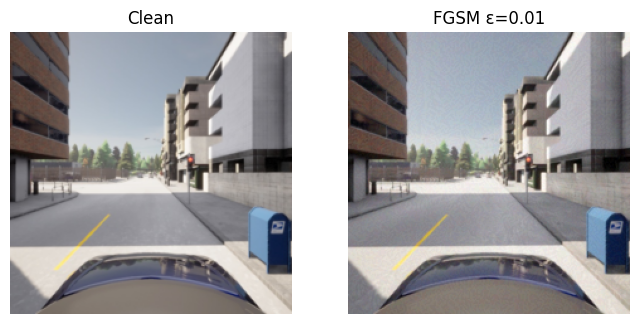


Epsilon     : 0.05
Probability : 0.0000
Prediction  : 0


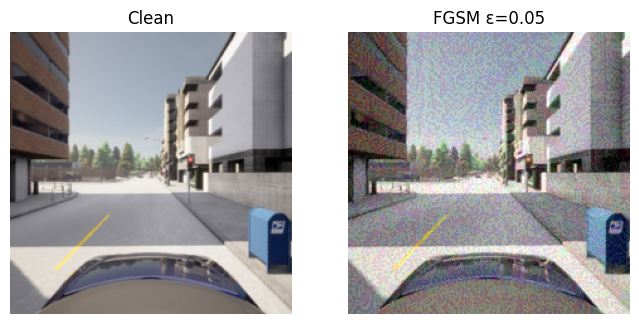


Epsilon     : 0.1
Probability : 0.0003
Prediction  : 0


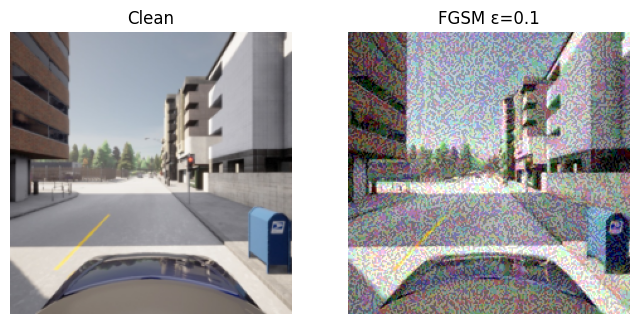

In [ ]:
epsilons = [0.01, 0.05, 0.1]

for eps in epsilons:

    adv_image = generate_adversarial_example(
        model,
        image,
        label,
        eps
    )

    with torch.no_grad():

        output = model(
            adv_image.unsqueeze(0).to(device)
        )

        prob = torch.sigmoid(output).item()

        pred = int(prob > 0.5)

    print(f"\nEpsilon     : {eps}")
    print(f"Probability : {prob:.4f}")
    print(f"Prediction  : {pred}")

    plt.figure(figsize=(8,4))

    plt.subplot(1,2,1)
    plt.imshow(image.permute(1,2,0))
    plt.title("Clean")
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.imshow(adv_image.cpu().permute(1,2,0))
    plt.title(f"FGSM ε={eps}")
    plt.axis("off")

    plt.show()

In [ ]:
difference = (adv_image.cpu() - image).abs()

print("Maximum perturbation :", difference.max().item())
print("Mean perturbation    :", difference.mean().item())

Maximum perturbation : 0.10000002384185791
Mean perturbation    : 0.09911441057920456


In [ ]:
epsilons = [0.01, 0.05, 0.1]

for eps in epsilons:

    adv_image = generate_adversarial_example(
        model,
        image,
        label,
        eps
    )

    with torch.no_grad():

        output = model(
            adv_image.unsqueeze(0).to(device)
        )

        prob = torch.sigmoid(output).item()

        pred = int(prob > 0.5)

    print(f"\nEpsilon     : {eps}")
    print(f"Probability : {prob:.4f}")
    print(f"Prediction  : {pred}")


Epsilon     : 0.01
Probability : 0.0002
Prediction  : 0

Epsilon     : 0.05
Probability : 0.0000
Prediction  : 0

Epsilon     : 0.1
Probability : 0.0003
Prediction  : 0


In [ ]:
task="has_vehicle"
model=create_model().to(device)
model.load_state_dict(
    torch.load(
        f"/content/drive/MyDrive/Data2/model/{task}_model.pth",
        map_location=device
    )
)
model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [ ]:
dataset=CarlaDataset(
    labels_test,
    test_rgb_path,
    task,
    transform
)
print("Datatset loaded sucessfully ")

Datatset loaded sucessfully 


In [ ]:
model.eval()
for i in range (len(dataset)):
  image,label=dataset[i]
  if label.item() !=1:
    continue
  with torch.no_grad():
    output=model(
        image.unsqueeze(0).to(device)
    )
    prob= torch.sigmoid(output).item()
    pred= int(prob>0.5)
    if pred==1:
      print(f"Correctly classified positive image found at index {i}")
      print(f"Probability : {prob:.4f} ")
      break

Correctly classified positive image found at index 2
Probability : 0.8074 


In [ ]:
index= 2
image,label = dataset[index]
print("Ground truth : " , int(label.item()))
with torch.no_grad():
  output= model(
      image.unsqueeze(0).to(device)
  )
  prob= torch.sigmoid(output).item()
  pred=int(prob>0.5)

print(f"Probability : {prob:.4f}")
print(f"Prediction: {pred}")

Ground truth :  1
Probability : 0.8074
Prediction: 1



Epsilon     : 0.01
Probability : 0.0000
Prediction  : 0


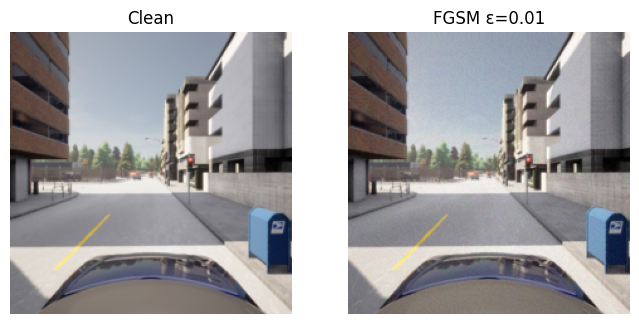


Epsilon     : 0.05
Probability : 0.0003
Prediction  : 0


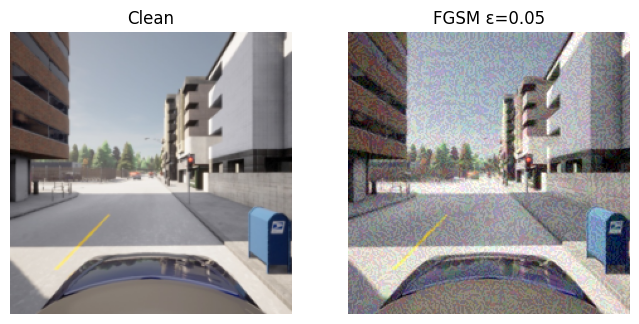


Epsilon     : 0.1
Probability : 0.0087
Prediction  : 0


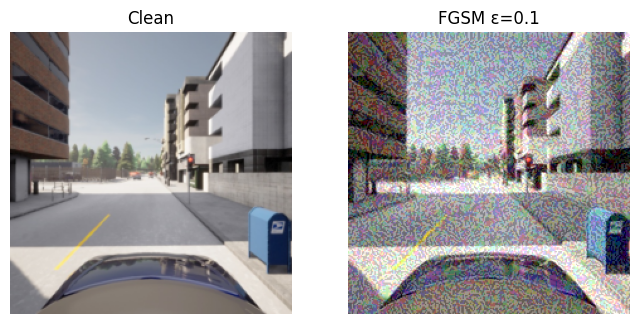

In [ ]:
epsilons = [0.01, 0.05, 0.1]

for eps in epsilons:

    adv_image = generate_adversarial_example(
        model,
        image,
        label,
        eps
    )

    with torch.no_grad():

        output = model(
            adv_image.unsqueeze(0).to(device)
        )

        prob = torch.sigmoid(output).item()

        pred = int(prob > 0.5)

    print(f"\nEpsilon     : {eps}")
    print(f"Probability : {prob:.4f}")
    print(f"Prediction  : {pred}")

    plt.figure(figsize=(8,4))

    plt.subplot(1,2,1)
    plt.imshow(image.permute(1,2,0))
    plt.title("Clean")
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.imshow(adv_image.cpu().permute(1,2,0))
    plt.title(f"FGSM ε={eps}")
    plt.axis("off")

    plt.show()

In [ ]:
difference = (adv_image.cpu() - image).abs()

print("Maximum perturbation :", difference.max().item())
print("Mean perturbation    :", difference.mean().item())

Maximum perturbation : 0.10000002384185791
Mean perturbation    : 0.09916383028030396


In [ ]:
epsilons = [0.01, 0.05, 0.1]

for eps in epsilons:

    adv_image = generate_adversarial_example(
        model,
        image,
        label,
        eps
    )

    with torch.no_grad():

        output = model(
            adv_image.unsqueeze(0).to(device)
        )

        prob = torch.sigmoid(output).item()

        pred = int(prob > 0.5)

    print(f"\nEpsilon     : {eps}")
    print(f"Probability : {prob:.4f}")
    print(f"Prediction  : {pred}")


Epsilon     : 0.01
Probability : 0.0000
Prediction  : 0

Epsilon     : 0.05
Probability : 0.0003
Prediction  : 0

Epsilon     : 0.1
Probability : 0.0087
Prediction  : 0


In [15]:
import torch

task = "has_pedestrian"

model = create_model().to(device)

model.load_state_dict(
    torch.load(
        "/content/drive/MyDrive/Data2/model/has_pedestrian_model.pth",
        map_location=device
    )
)

model.eval()

print("Pedestrian model loaded.")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 115MB/s]


Pedestrian model loaded.


In [16]:
pedestrian_dataset = CarlaDataset(
    dataframe=labels_test,
    image_dir=test_rgb_path,
    label_column="has_pedestrian",
    transform=transform
)

print("Dataset Size:", len(pedestrian_dataset))

Dataset Size: 3600


In [14]:
from sklearn.metrics import recall_score

def evaluate_clean_recall(
    model,
    dataset
):

    model.eval()

    y_true = []
    y_pred = []

    with torch.no_grad():

        for image, label in dataset:

            image = image.unsqueeze(0).to(device)

            output = model(image)

            probability = torch.sigmoid(output).item()

            prediction = int(probability > 0.5)

            y_true.append(int(label.item()))
            y_pred.append(prediction)

    recall = recall_score(
        y_true,
        y_pred,
        zero_division=0
    )

    print("\nCLEAN ")
    print("Actual Positives   :", sum(y_true))
    print("Predicted Positives:", sum(y_pred))
    print("Recall             :", recall)

    return recall

In [ ]:
from sklearn.metrics import recall_score

def evaluate_fgsm_recall(
    model,
    dataset,
    epsilon
):

    model.eval()

    y_true = []
    y_pred = []

    for image, label in dataset:

        adv_image = generate_adversarial_example(
            model,
            image,
            label,
            epsilon
        )

        with torch.no_grad():

            output = model(
                adv_image.unsqueeze(0).to(device)
            )

            probability = torch.sigmoid(output).item()

            prediction = int(probability > 0.5)

        y_true.append(int(label.item()))
        y_pred.append(prediction)

    recall = recall_score(
        y_true,
        y_pred,
        zero_division=0
    )

    print("\n FGSM ")
    print("Epsilon            :", epsilon)
    print("Actual Positives   :", sum(y_true))
    print("Predicted Positives:", sum(y_pred))
    print("Recall             :", recall)

    return recall

In [ ]:
clean_recall = evaluate_clean_recall(
    model,
    pedestrian_dataset
)

epsilons = [0.01, 0.05, 0.10]

for eps in epsilons:

    adv_recall = evaluate_fgsm_recall(
        model,
        pedestrian_dataset,
        eps
    )
    print(
        f"Recall Drop = {clean_recall - adv_recall:.4f}"
    )


CLEAN 
Actual Positives   : 706
Predicted Positives: 88
Recall             : 0.06657223796033994

 FGSM 
Epsilon            : 0.01
Actual Positives   : 706
Predicted Positives: 2792
Recall             : 0.0
Recall Drop = 0.0666

 FGSM 
Epsilon            : 0.05
Actual Positives   : 706
Predicted Positives: 2829
Recall             : 0.0
Recall Drop = 0.0666

 FGSM 
Epsilon            : 0.1
Actual Positives   : 706
Predicted Positives: 2759
Recall             : 0.00141643059490085
Recall Drop = 0.0652


In [13]:
from sklearn.metrics import recall_score, confusion_matrix

def evaluate_fgsm_recall(
    model,
    dataset,
    epsilon
):

    model.eval()

    y_true = []
    y_pred = []

    for image, label in dataset:

        adv_image = generate_adversarial_example(
            model,
            image,
            label,
            epsilon
        )

        with torch.no_grad():

            output = model(
                adv_image.unsqueeze(0).to(device)
            )

            probability = torch.sigmoid(output).item()

            prediction = int(probability > 0.5)

        y_true.append(int(label.item()))
        y_pred.append(prediction)

    cm = confusion_matrix(y_true, y_pred)

    print("\n========== FGSM ==========")
    print("Epsilon :", epsilon)
    print("\nConfusion Matrix")
    print(cm)

    print(f"\nTrue Negatives : {cm[0,0]}")
    print(f"False Positives: {cm[0,1]}")
    print(f"False Negatives: {cm[1,0]}")
    print(f"True Positives : {cm[1,1]}")

    recall = recall_score(
        y_true,
        y_pred,
        zero_division=0
    )

    print(f"\nRecall : {recall:.4f}")

    return recall

In [ ]:
evaluate_fgsm_recall(
    model,
    pedestrian_dataset,
    0.01
)

Streaming output truncated to the last 5000 lines.
Gradient max : 0.0008824475225992501
Gradient min : -0.0011197327403351665
Gradient mean: 3.746115861957833e-09
Gradient max : 0.0012864837190136313
Gradient min : -0.0015462394803762436
Gradient mean: 5.5717004343591725e-09
Gradient max : 0.002526909811422229
Gradient min : -0.0015847717877477407
Gradient mean: 6.56494303363786e-10
Gradient max : 0.005821069702506065
Gradient min : -0.0025304234586656094
Gradient mean: -4.990712842989353e-10
Gradient max : 0.005095404572784901
Gradient min : -0.004258633125573397
Gradient mean: 1.009685135500149e-08
Gradient max : 0.32326215505599976
Gradient min : -0.1493205577135086
Gradient mean: -3.1785657483851537e-07
Gradient max : 0.00171098078135401
Gradient min : -0.0016644501592963934
Gradient mean: 2.720844349823892e-08
Gradient max : 0.0005489040049724281
Gradient min : -0.0007334856200031936
Gradient mean: -1.3304854995510595e-09
Gradient max : 0.001001619384624064
Gradient min : -0.00123

0.9787535410764873

In [17]:
from sklearn.metrics import confusion_matrix

y_true = []
y_pred = []

model.eval()

with torch.no_grad():

    for image, label in pedestrian_dataset:

        output = model(
            image.unsqueeze(0).to(device)
        )

        pred = int(
            torch.sigmoid(output).item() > 0.5
        )

        y_true.append(int(label.item()))
        y_pred.append(pred)

cm = confusion_matrix(y_true, y_pred)

print(cm)

[[2853   41]
 [ 659   47]]


In [18]:
print("\nFirst 20 predictions")

for i in range(20):
    print(
        f"GT={y_true[i]}  Pred={y_pred[i]}"
    )


First 20 predictions
GT=0  Pred=0
GT=0  Pred=0
GT=0  Pred=0
GT=0  Pred=0
GT=0  Pred=0
GT=0  Pred=0
GT=0  Pred=0
GT=0  Pred=0
GT=0  Pred=0
GT=0  Pred=0
GT=0  Pred=0
GT=0  Pred=0
GT=0  Pred=0
GT=0  Pred=0
GT=0  Pred=0
GT=0  Pred=0
GT=0  Pred=0
GT=0  Pred=0
GT=0  Pred=0
GT=0  Pred=0


In [20]:
from torch.utils.data import DataLoader

pedestrian_dataset = CarlaDataset(
    dataframe=labels_test,
    image_dir=test_rgb_path,
    label_column="has_pedestrian",
    transform=transform
)

pedestrian_loader = DataLoader(
    pedestrian_dataset,
    batch_size=32,
    shuffle=False
)

In [21]:
import torch
import torch.nn.functional as F

def fgsm_attack(image, epsilon, gradient):

    perturbed = image + epsilon * gradient.sign()

    perturbed = torch.clamp(
        perturbed,
        0,
        1
    )

    return perturbed

In [22]:
def generate_adversarial_example(
    model,
    image,
    label,
    epsilon
):

    model.eval()

    image = image.unsqueeze(0).to(device)
    image = image.clone().detach()
    image.requires_grad_(True)

    label = label.float().view(1, 1).to(device)

    output = model(image)

    loss = F.binary_cross_entropy_with_logits(
        output,
        label
    )

    model.zero_grad()

    loss.backward()

    gradient = image.grad.detach()

    adv_image = fgsm_attack(
        image,
        epsilon,
        gradient
    )

    return adv_image.squeeze(0).detach()

In [23]:
from torch.utils.data import DataLoader

pedestrian_dataset = CarlaDataset(
    dataframe=labels_test,
    image_dir=test_rgb_path,
    label_column="has_pedestrian",
    transform=transform
)

pedestrian_loader = DataLoader(
    pedestrian_dataset,
    batch_size=32,
    shuffle=False
)

print("Dataset size:", len(pedestrian_dataset))

Dataset size: 3600


In [24]:
from sklearn.metrics import confusion_matrix, recall_score

def evaluate_clean_loader(model, loader):

    model.eval()

    y_true = []
    y_pred = []

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)

            outputs = model(images)

            probabilities = torch.sigmoid(outputs)

            predictions = (
                probabilities > 0.5
            ).int()

            y_true.extend(
                labels.cpu().numpy().astype(int)
            )

            y_pred.extend(
                predictions.cpu().numpy().flatten()
            )

    cm = confusion_matrix(
        y_true,
        y_pred
    )

    recall = recall_score(
        y_true,
        y_pred,
        zero_division=0
    )

    print("CLEAN CONFUSION MATRIX")
    print(cm)

    print("\nTN:", cm[0,0])
    print("FP:", cm[0,1])
    print("FN:", cm[1,0])
    print("TP:", cm[1,1])

    print("\nClean Recall:", recall)

    return recall

In [41]:
pedestrian_model = create_model().to(device)

pedestrian_model.load_state_dict(
    torch.load(
        "/content/drive/MyDrive/Data2/model/has_pedestrian_model.pth",
        map_location=device
    )
)

pedestrian_model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [42]:
clean_recall = evaluate_clean_loader(
    pedestrian_model,
    pedestrian_loader
)

CLEAN CONFUSION MATRIX
[[2853   41]
 [ 659   47]]

TN: 2853
FP: 41
FN: 659
TP: 47

Clean Recall: 0.06657223796033994


In [27]:
def create_adversarial_dataset(
    model,
    dataset,
    epsilon
):

    adversarial_images = []
    labels = []

    for i in range(len(dataset)):

        image, label = dataset[i]

        adv_image = generate_adversarial_example(
            model,
            image,
            label,
            epsilon
        )

        adversarial_images.append(
            adv_image.cpu()
        )

        labels.append(
            label
        )

    return adversarial_images, labels

In [28]:
adv_images_001, adv_labels_001 = create_adversarial_dataset(
    pedestrian_model,
    pedestrian_dataset,
    epsilon=0.01
)

In [29]:
def evaluate_adversarial_images(
    model,
    adversarial_images,
    labels
):

    model.eval()

    y_true = []
    y_pred = []

    with torch.no_grad():

        for image, label in zip(
            adversarial_images,
            labels
        ):

            image = image.unsqueeze(0).to(device)

            output = model(image)

            probability = torch.sigmoid(
                output
            ).item()

            prediction = int(
                probability > 0.5
            )

            y_true.append(
                int(label.item())
            )

            y_pred.append(
                prediction
            )

    cm = confusion_matrix(
        y_true,
        y_pred
    )

    recall = recall_score(
        y_true,
        y_pred,
        zero_division=0
    )

    print("ADVERSARIAL CONFUSION MATRIX")
    print(cm)

    print("\nTN:", cm[0,0])
    print("FP:", cm[0,1])
    print("FN:", cm[1,0])
    print("TP:", cm[1,1])

    print("\nAdversarial Recall:", recall)

    return recall

In [30]:
adv_recall_001 = evaluate_adversarial_images(
    pedestrian_model,
    adv_images_001,
    adv_labels_001
)

print(
    "\nRecall Drop:",
    clean_recall - adv_recall_001
)

ADVERSARIAL CONFUSION MATRIX
[[ 102 2792]
 [ 706    0]]

TN: 102
FP: 2792
FN: 706
TP: 0

Adversarial Recall: 0.0

Recall Drop: 0.06657223796033994


In [31]:
def inspect_fgsm_single_sample(
    model,
    dataset,
    index,
    epsilon
):

    image, label = dataset[index]

    model.eval()

    # Clean prediction
    with torch.no_grad():

        clean_output = model(
            image.unsqueeze(0).to(device)
        )

        clean_prob = torch.sigmoid(
            clean_output
        ).item()

    # Generate FGSM
    adv_image = generate_adversarial_example(
        model,
        image,
        label,
        epsilon
    )

    # Adversarial prediction
    with torch.no_grad():

        adv_output = model(
            adv_image.unsqueeze(0).to(device)
        )

        adv_prob = torch.sigmoid(
            adv_output
        ).item()

    print("Index:", index)
    print("Ground truth:", int(label.item()))

    print("\nClean:")
    print("Logit:", clean_output.item())
    print("Probability:", clean_prob)
    print("Prediction:", int(clean_prob > 0.5))

    print("\nAdversarial:")
    print("Logit:", adv_output.item())
    print("Probability:", adv_prob)
    print("Prediction:", int(adv_prob > 0.5))

    print("\nChange in probability:",
          adv_prob - clean_prob)

In [32]:
inspect_fgsm_single_sample(
    pedestrian_model,
    pedestrian_dataset,
    index=260,
    epsilon=0.01
)

Index: 260
Ground truth: 1

Clean:
Logit: 1.1630903482437134
Probability: 0.7618938088417053
Prediction: 1

Adversarial:
Logit: -11.659865379333496
Probability: 8.633383913547732e-06
Prediction: 0

Change in probability: -0.7618851754577918


In [33]:
for i in range(len(pedestrian_dataset)):

    _, label = pedestrian_dataset[i]

    if label.item() == 0:

        print("Negative sample:", i)
        break

Negative sample: 0


In [34]:
inspect_fgsm_single_sample(
    pedestrian_model,
    pedestrian_dataset,
    index=0,
    epsilon=0.01
)

Index: 0
Ground truth: 0

Clean:
Logit: -9.671560287475586
Probability: 6.304743146756664e-05
Prediction: 0

Adversarial:
Logit: 0.3036513328552246
Probability: 0.5753348469734192
Prediction: 1

Change in probability: 0.5752717995419516


In [35]:
def check_perturbation(model, dataset, index, epsilon):

    image, label = dataset[index]

    adv_image = generate_adversarial_example(
        model,
        image,
        label,
        epsilon
    )

    difference = (
        adv_image.cpu() - image.cpu()
    ).abs()

    print("Index:", index)
    print("Label:", int(label.item()))
    print("Epsilon:", epsilon)
    print("Maximum perturbation:", difference.max().item())
    print("Mean perturbation:", difference.mean().item())

In [36]:
check_perturbation(
    pedestrian_model,
    pedestrian_dataset,
    260,
    0.01
)

check_perturbation(
    pedestrian_model,
    pedestrian_dataset,
    0,
    0.01
)

Index: 260
Label: 1
Epsilon: 0.01
Maximum perturbation: 0.010000020265579224
Mean perturbation: 0.00999654270708561
Index: 0
Label: 0
Epsilon: 0.01
Maximum perturbation: 0.010000020265579224
Mean perturbation: 0.009995030239224434


In [37]:
epsilons = [0.05, 0.10]

pedestrian_results = []

for eps in epsilons:

    adv_images, adv_labels = create_adversarial_dataset(
        pedestrian_model,
        pedestrian_dataset,
        epsilon=eps
    )

    adv_recall = evaluate_adversarial_images(
        pedestrian_model,
        adv_images,
        adv_labels
    )

    recall_drop = clean_recall - adv_recall

    pedestrian_results.append({
        "Epsilon": eps,
        "Clean Recall": clean_recall,
        "Adversarial Recall": adv_recall,
        "Recall Drop": recall_drop
    })

    print(
        f"\nε = {eps}"
    )
    print(
        f"Clean Recall       : {clean_recall:.4f}"
    )
    print(
        f"Adversarial Recall : {adv_recall:.4f}"
    )
    print(
        f"Recall Drop        : {recall_drop:.4f}"
    )

ADVERSARIAL CONFUSION MATRIX
[[  65 2829]
 [ 706    0]]

TN: 65
FP: 2829
FN: 706
TP: 0

Adversarial Recall: 0.0

ε = 0.05
Clean Recall       : 0.0666
Adversarial Recall : 0.0000
Recall Drop        : 0.0666
ADVERSARIAL CONFUSION MATRIX
[[ 136 2758]
 [ 705    1]]

TN: 136
FP: 2758
FN: 705
TP: 1

Adversarial Recall: 0.00141643059490085

ε = 0.1
Clean Recall       : 0.0666
Adversarial Recall : 0.0014
Recall Drop        : 0.0652


In [51]:
traffic_light_model = create_model().to(device)

traffic_light_model.load_state_dict(
    torch.load(
        "/content/drive/MyDrive/Data2/model/has_traffic_light_model.pth",
        map_location=device
    )
)

traffic_light_model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [52]:
traffic_light_dataset = CarlaDataset(
    dataframe=labels_test,
    image_dir=test_rgb_path,
    label_column="has_traffic_light",
    transform=transform
)

traffic_light_loader = DataLoader(
    traffic_light_dataset,
    batch_size=32,
    shuffle=False
)

In [53]:
clean_recall = evaluate_clean_loader(
    traffic_light_model,
    traffic_light_loader
)

CLEAN CONFUSION MATRIX
[[ 862  154]
 [  90 2494]]

TN: 862
FP: 154
FN: 90
TP: 2494

Clean Recall: 0.9651702786377709


In [46]:
adv_images_001, adv_labels_001 = create_adversarial_dataset(
    traffic_light_model,
    traffic_light_dataset,
    epsilon=0.01
)

In [48]:
adv_recall_001 = evaluate_adversarial_images(
    traffic_light_model,
    adv_images_001,
    adv_labels_001
)

print(
    "\nRecall Drop:",
    clean_recall - adv_recall_001
)

ADVERSARIAL CONFUSION MATRIX
[[  23  993]
 [2584    0]]

TN: 23
FP: 993
FN: 2584
TP: 0

Adversarial Recall: 0.0

Recall Drop: 0.9651702786377709


In [50]:
epsilons = [0.05, 0.10]

traffic_light_results = []

for eps in epsilons:

    adv_images, adv_labels = create_adversarial_dataset(
        traffic_light_model,
        traffic_light_dataset,
        epsilon=eps
    )

    adv_recall = evaluate_adversarial_images(
        traffic_light_model,
        adv_images,
        adv_labels
    )

    recall_drop = clean_recall - adv_recall

    traffic_light_results.append({
        "Epsilon": eps,
        "Clean Recall": clean_recall,
        "Adversarial Recall": adv_recall,
        "Recall Drop": recall_drop
    })

    print(
        f"\nε = {eps}"
    )
    print(
        f"Clean Recall       : {clean_recall:.4f}"
    )
    print(
        f"Adversarial Recall : {adv_recall:.4f}"
    )
    print(
        f"Recall Drop        : {recall_drop:.4f}"
    )

ADVERSARIAL CONFUSION MATRIX
[[  39  977]
 [2584    0]]

TN: 39
FP: 977
FN: 2584
TP: 0

Adversarial Recall: 0.0

ε = 0.05
Clean Recall       : 0.9652
Adversarial Recall : 0.0000
Recall Drop        : 0.9652
ADVERSARIAL CONFUSION MATRIX
[[ 443  573]
 [2584    0]]

TN: 443
FP: 573
FN: 2584
TP: 0

Adversarial Recall: 0.0

ε = 0.1
Clean Recall       : 0.9652
Adversarial Recall : 0.0000
Recall Drop        : 0.9652


In [54]:
vehicle_model= create_model().to(device)

vehicle_model.load_state_dict(
    torch.load(
        "/content/drive/MyDrive/Data2/model/has_vehicle_model.pth",
        map_location=device
    )
)

vehicle_model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [55]:
vehicle_dataset = CarlaDataset(
    dataframe=labels_test,
    image_dir=test_rgb_path,
    label_column="has_vehicle",
    transform=transform
)

vehicle_loader = DataLoader(
    vehicle_dataset,
    batch_size=32,
    shuffle=False
)

In [57]:
clean_recall = evaluate_clean_loader(
    vehicle_model,
    vehicle_loader
)

CLEAN CONFUSION MATRIX
[[ 900    0]
 [2068  632]]

TN: 900
FP: 0
FN: 2068
TP: 632

Clean Recall: 0.23407407407407407


In [59]:
adv_images_001, adv_labels_001 = create_adversarial_dataset(
    vehicle_model,
    vehicle_dataset,
    epsilon=0.01
)

In [60]:
adv_recall_001 = evaluate_adversarial_images(
    vehicle_model,
    adv_images_001,
    adv_labels_001
)

print(
    "\nRecall Drop:",
    clean_recall - adv_recall_001
)

ADVERSARIAL CONFUSION MATRIX
[[ 705  195]
 [2698    2]]

TN: 705
FP: 195
FN: 2698
TP: 2

Adversarial Recall: 0.0007407407407407407

Recall Drop: 0.23333333333333334


In [61]:
epsilons = [0.05, 0.10]

vehicle_results = []

for eps in epsilons:

    adv_images, adv_labels = create_adversarial_dataset(
        vehicle_model,
        vehicle_dataset,
        epsilon=eps
    )

    adv_recall = evaluate_adversarial_images(
        vehicle_model,
        adv_images,
        adv_labels
    )

    recall_drop = clean_recall - adv_recall

    vehicle_results.append({
        "Epsilon": eps,
        "Clean Recall": clean_recall,
        "Adversarial Recall": adv_recall,
        "Recall Drop": recall_drop
    })

    print(
        f"\nε = {eps}"
    )
    print(
        f"Clean Recall       : {clean_recall:.4f}"
    )
    print(
        f"Adversarial Recall : {adv_recall:.4f}"
    )
    print(
        f"Recall Drop        : {recall_drop:.4f}"
    )

ADVERSARIAL CONFUSION MATRIX
[[ 614  286]
 [2700    0]]

TN: 614
FP: 286
FN: 2700
TP: 0

Adversarial Recall: 0.0

ε = 0.05
Clean Recall       : 0.2341
Adversarial Recall : 0.0000
Recall Drop        : 0.2341
ADVERSARIAL CONFUSION MATRIX
[[ 810   90]
 [2700    0]]

TN: 810
FP: 90
FN: 2700
TP: 0

Adversarial Recall: 0.0

ε = 0.1
Clean Recall       : 0.2341
Adversarial Recall : 0.0000
Recall Drop        : 0.2341


Exercise 9

Implementing ECE computation

In [62]:
import numpy as np
import torch

def compute_ece(model, dataloader, n_bins=10):

    model.eval()

    confidences = []
    predictions = []
    labels_all = []

    with torch.no_grad():

        for images, labels in dataloader:

            images = images.to(device)

            outputs = model(images)

            probs = torch.sigmoid(outputs).squeeze()

            preds = (probs >= 0.5).float()

            confidences.extend(
                probs.cpu().numpy()
            )

            predictions.extend(
                preds.cpu().numpy()
            )

            labels_all.extend(
                labels.numpy()
            )

    confidences = np.array(confidences)
    predictions = np.array(predictions)
    labels_all = np.array(labels_all)

    bin_boundaries = np.linspace(
        0,
        1,
        n_bins + 1
    )

    ece = 0.0

    for i in range(n_bins):

        mask = (
            (confidences > bin_boundaries[i]) &
            (confidences <= bin_boundaries[i + 1])
        )

        if np.sum(mask) > 0:

            acc = np.mean(
                predictions[mask] ==
                labels_all[mask]
            )

            conf = np.mean(
                confidences[mask]
            )

            ece += (
                np.sum(mask) / len(confidences)
            ) * abs(acc - conf)

    return ece

In [63]:
import matplotlib.pyplot as plt

def reliability_diagram(
    model,
    dataloader,
    n_bins=10,
    title=""
):

    model.eval()

    confidences = []
    predictions = []
    labels_all = []

    with torch.no_grad():

        for images, labels in dataloader:

            images = images.to(device)

            outputs = model(images)

            probs = torch.sigmoid(outputs).squeeze()

            preds = (probs >= 0.5).float()

            confidences.extend(
                probs.cpu().numpy()
            )

            predictions.extend(
                preds.cpu().numpy()
            )

            labels_all.extend(
                labels.numpy()
            )

    confidences = np.array(confidences)
    predictions = np.array(predictions)
    labels_all = np.array(labels_all)

    bins = np.linspace(0, 1, n_bins + 1)

    bin_accs = []
    bin_confs = []

    for i in range(n_bins):

        mask = (
            (confidences > bins[i]) &
            (confidences <= bins[i+1])
        )

        if np.sum(mask) > 0:

            bin_accs.append(
                np.mean(
                    predictions[mask] ==
                    labels_all[mask]
                )
            )

            bin_confs.append(
                np.mean(
                    confidences[mask]
                )
            )

    plt.figure(figsize=(6,6))

    plt.plot(
        [0,1],
        [0,1],
        '--',
        label='Perfect Calibration'
    )

    plt.plot(
        bin_confs,
        bin_accs,
        marker='o'
    )

    plt.xlabel("Confidence")

    plt.ylabel("Accuracy")

    plt.title(title)

    plt.grid(True)

    plt.show()

Evaluating models by plotting reliability diagram

has_pedestrian
ECE = 0.7735


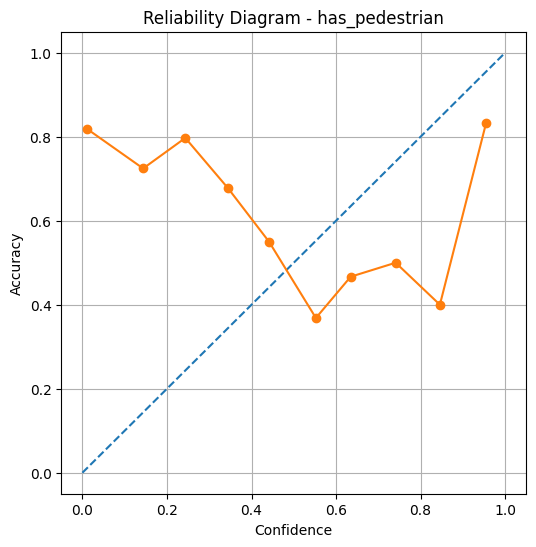

has_traffic_light
ECE = 0.2408


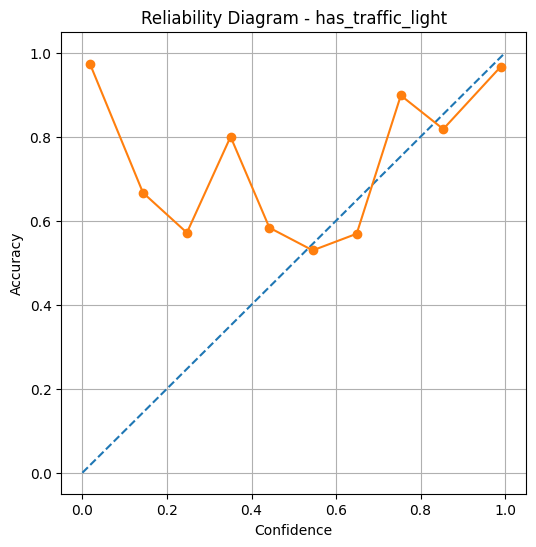

has_vehicle
ECE = 0.2885


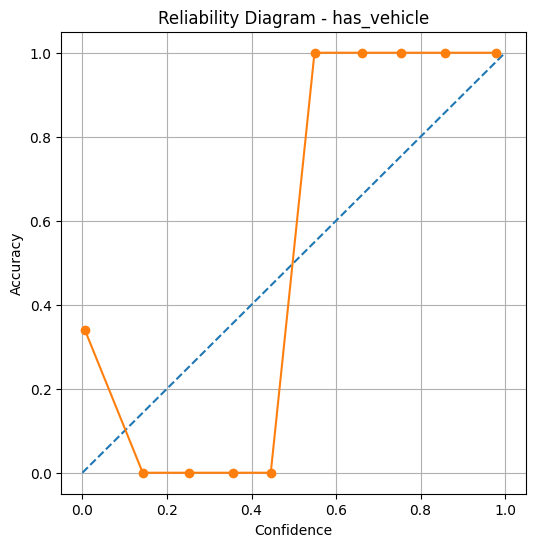

In [64]:
tasks = [
    "has_pedestrian",
    "has_traffic_light",
    "has_vehicle"
]

for task in tasks:
    print(task)

    model = create_model().to(device)

    model.load_state_dict(
        torch.load(
            f"/content/drive/MyDrive/Data2/model/{task}_model.pth",
            map_location=device
        )
    )

    dataset = CarlaDataset(
        dataframe=labels_test,
        image_dir=test_rgb_path,
        label_column=task,
        transform=transform
    )

    loader = DataLoader(
        dataset,
        batch_size=32,
        shuffle=False
    )

    ece = compute_ece(
        model,
        loader
    )

    print(
        f"ECE = {ece:.4f}"
    )

    reliability_diagram(
        model,
        loader,
        title=f"Reliability Diagram - {task}"
    )

Finding best temperature

In [65]:
import numpy as np
import torch
import torch.nn.functional as F

def find_best_temperature(model, dataloader):

    model.eval()

    logits_list = []
    labels_list = []

    with torch.no_grad():

        for images, labels in dataloader:

            images = images.to(device)

            logits = model(images)

            logits_list.append(
                logits.cpu()
            )

            labels_list.append(
                labels.unsqueeze(1)
            )

    logits = torch.cat(logits_list)
    labels = torch.cat(labels_list)

    best_T = 1.0
    best_nll = float("inf")

    temperatures = np.arange(
        0.5,
        3.1,
        0.1
    )

    for T in temperatures:

        scaled_logits = logits / T

        nll = F.binary_cross_entropy_with_logits(
            scaled_logits,
            labels
        ).item()

        if nll < best_nll:

            best_nll = nll
            best_T = T

    return best_T, best_nll

In [66]:
def compute_ece_temperature(
    model,
    dataloader,
    T,
    n_bins=10
):

    model.eval()

    confidences = []
    predictions = []
    labels_all = []

    with torch.no_grad():

        for images, labels in dataloader:

            images = images.to(device)

            logits = model(images)

            probs = torch.sigmoid(
                logits / T
            ).squeeze()

            preds = (
                probs >= 0.5
            ).float()

            confidences.extend(
                probs.cpu().numpy()
            )

            predictions.extend(
                preds.cpu().numpy()
            )

            labels_all.extend(
                labels.numpy()
            )

    confidences = np.array(confidences)
    predictions = np.array(predictions)
    labels_all = np.array(labels_all)

    bins = np.linspace(
        0,
        1,
        n_bins + 1
    )

    ece = 0.0

    for i in range(n_bins):

        mask = (
            (confidences > bins[i]) &
            (confidences <= bins[i+1])
        )

        if np.sum(mask) > 0:

            acc = np.mean(
                predictions[mask] ==
                labels_all[mask]
            )

            conf = np.mean(
                confidences[mask]
            )

            ece += (
                np.sum(mask) /
                len(confidences)
            ) * abs(
                acc - conf
            )

    return ece

computing ECE before and after temperature scaling

In [67]:
tasks = [
    "has_pedestrian",
    "has_traffic_light",
    "has_vehicle"
]

for task in tasks:

    print(task)

    model = create_model().to(device)

    model.load_state_dict(
        torch.load(
            f"/content/drive/MyDrive/Data2/model/{task}_model.pth",
            map_location=device
        )
    )

    # Validation set
    val_dataset = CarlaDataset(
        dataframe=labels_val,
        image_dir="/content/drive/MyDrive/Data2/validation/rgb-front",
        label_column=task,
        transform=transform
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=32,
        shuffle=False
    )

    best_T, best_nll = find_best_temperature(
        model,
        val_loader
    )

    print(
        f"Best T = {best_T:.1f}"
    )

    print(
        f"Validation NLL = {best_nll:.4f}"
    )

    # Test set
    test_dataset = CarlaDataset(
        dataframe=labels_test,
        image_dir=test_rgb_path,
        label_column=task,
        transform=transform
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=32,
        shuffle=False
    )

    ece_before = compute_ece(
        model,
        test_loader
    )

    ece_after = compute_ece_temperature(
        model,
        test_loader,
        best_T
    )

    print(
        f"ECE Before = {ece_before:.4f}"
    )

    print(
        f"ECE After  = {ece_after:.4f}"
    )

has_pedestrian
Best T = 3.0
Validation NLL = 0.6215
ECE Before = 0.7735
ECE After  = 0.6517
has_traffic_light
Best T = 1.1
Validation NLL = 0.1488
ECE Before = 0.2408
ECE After  = 0.2355
has_vehicle
Best T = 3.0
Validation NLL = 1.1288
ECE Before = 0.2885
ECE After  = 0.3261


Defining confusion matrix and cost calculation function

In [68]:
from sklearn.metrics import confusion_matrix
import torch
import numpy as np

C_FN = 100
C_FP = 1

TAU_STAR = 1 / 101  # 0.0099

def compute_cost(
    model,
    dataloader,
    threshold,
    temperature=1.0
):

    model.eval()

    y_true = []
    y_pred = []

    with torch.no_grad():

        for images, labels in dataloader:

            images = images.to(device)

            logits = model(images)

            probs = torch.sigmoid(
                logits / temperature
            ).squeeze()

            preds = (
                probs >= threshold
            ).cpu().numpy()

            y_pred.extend(preds)

            y_true.extend(
                labels.numpy()
            )

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        y_pred
    ).ravel()

    loss = (
        C_FN * fn +
        C_FP * fp
    )

    return loss, fn, fp

Evaluating loss for uncalibrated and calibrated models

In [69]:
results = []

thresholds = [
    ("0.5", 0.5),
    ("tau*", 1/101)
]

for name, threshold in thresholds:

    loss, fn, fp = compute_cost(
        model,
        test_loader,
        threshold=threshold,
        temperature=1.0
    )

    results.append([
        "Uncalibrated",
        name,
        loss,
        fn,
        fp
    ])

for name, threshold in thresholds:

    loss, fn, fp = compute_cost(
        model,
        test_loader,
        threshold=threshold,
        temperature=3.0
    )

    results.append([
        "Calibrated",
        name,
        loss,
        fn,
        fp
    ])

import pandas as pd

results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Threshold",
        "Total Loss",
        "FN",
        "FP"
    ]
)

print(results_df)

          Model Threshold  Total Loss    FN   FP
0  Uncalibrated       0.5      206800  2068    0
1  Uncalibrated      tau*      141902  1419    2
2    Calibrated       0.5      206800  2068    0
3    Calibrated      tau*         900     0  900
